In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
# Replace with your actual dataset path
DATASET_ROOT = 'C:/Users/ejeme/Documents/WSI images for tumor detection in gastrointestinal cancer/'

# Compute mean and std
mean, std = compute_mean_std(DATASET_ROOT)
print("Mean:", mean)
print("Std:", std)

# Your transforms
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_set, val_set, test_set = split_and_balance_dataset(
    root=DATASET_ROOT,
    transform=transform,
    train_size=1/3,
    val_size=1/10
)

# Dataloaders
train_loader = DataLoader(train_set, batch_size=15, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=15, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=15, shuffle=False, num_workers=2)

100%|██████████| 1198/1198 [01:35<00:00, 12.60it/s]

Mean: tensor([0.7801, 0.6251, 0.7518])
Std: tensor([0.1205, 0.1491, 0.1078])


In [4]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallCNN(nn.Module):
    def __init__(self, p=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 20, 4, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p)
        self.dropout2d = nn.Dropout2d(p)
        self.conv2 = nn.Conv2d(20, 32, 4, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(p)            # train-time and MC-dropout layer
        self.fc1 = nn.Linear(32 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.dropout2d(self.conv2(x))))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.dropout(self.fc1(x)))   # dropout used here
        x = self.fc2(x)
        return x


# Initialize the model
cnn = SmallCNN().to(device)

In [5]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load trained cnn
cnn = SmallCNN().to(device)
checkpoint = torch.load("C:/Users/ejeme/Documents/python_repos/selective-classification/models_weights/cnn_wsi_binary_epoch0.pth", map_location=torch.device('cpu'))
cnn.load_state_dict(checkpoint)

<All keys matched successfully>

In [6]:
i = iter(test_loader)

In [38]:
batch = next(i)
images, labels = batch
images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

logits = cnn(images)

print('labels:',labels)
print('preds_:',np.argmax(F.softmax(logits, dim=1).cpu().detach(),axis=1))
print(F.softmax(logits, dim=1).cpu().detach())

labels: tensor([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0], device='cuda:0')
preds_: tensor([0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0])
tensor([[0.9715, 0.0285],
        [0.9760, 0.0240],
        [0.9335, 0.0665],
        [0.9984, 0.0016],
        [0.9669, 0.0331],
        [0.1704, 0.8296],
        [0.9796, 0.0204],
        [0.9768, 0.0232],
        [0.0792, 0.9208],
        [0.0632, 0.9368],
        [0.9419, 0.0581],
        [0.9953, 0.0047],
        [0.7542, 0.2458],
        [0.0889, 0.9111],
        [0.9336, 0.0664]])


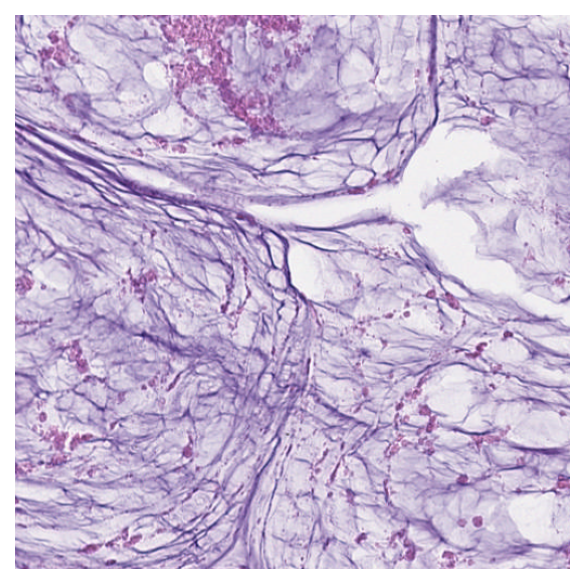

In [40]:
# Your dataset mean & std
mean = torch.tensor([0.7801, 0.6251, 0.7518]).view(3, 1, 1)
std = torch.tensor([0.1205, 0.1491, 0.1078]).view(3, 1, 1)
# Denormalize
img = images[-2].cpu() * std + mean
# Clamp to [0,1] for plotting
img = img.clamp(0, 1)
# Rearrange to (H, W, C)
img = img.permute(1, 2, 0).numpy()
# Plot
plt.imshow(img)
plt.axis("off")
plt.show()

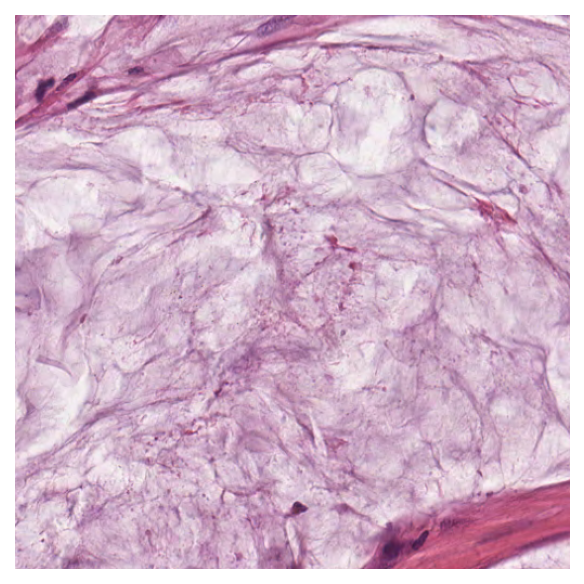

In [41]:
# Your dataset mean & std
mean = torch.tensor([0.7801, 0.6251, 0.7518]).view(3, 1, 1)
std = torch.tensor([0.1205, 0.1491, 0.1078]).view(3, 1, 1)
# Denormalize
img = images[-1].cpu() * std + mean
# Clamp to [0,1] for plotting
img = img.clamp(0, 1)
# Rearrange to (H, W, C)
img = img.permute(1, 2, 0).numpy()
# Plot
plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(6788, 3)
1s prop =  0.3320565704183854


,y_true,y_pred,kappa
0,0.0,0.0,0.985617
1,1.0,1.0,0.899486
2,1.0,1.0,0.952112
3,0.0,0.0,0.994921
4,0.0,0.0,0.978682


In [9]:
train_set_SR = sgp_df_SR.iloc[:3*int(len(sgp_df_SR)/4)]
train_set_SR = train_set_SR.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set_SR = sgp_df_SR.iloc[3*int(len(sgp_df_SR)/4):]

In [10]:
delta = 0.005

In [11]:
color_map = {'standard': "#d51414",
             'FP': "#91790e",
             'FN': "#189b11",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#d51de2",
             'SP': "#129EAD",
             'PPV': "#676767"}

standard  bounds


 98%|█████████▊| 49/50 [00:02<00:00, 23.54it/s]


FPR  bounds


 98%|█████████▊| 49/50 [00:01<00:00, 26.79it/s]


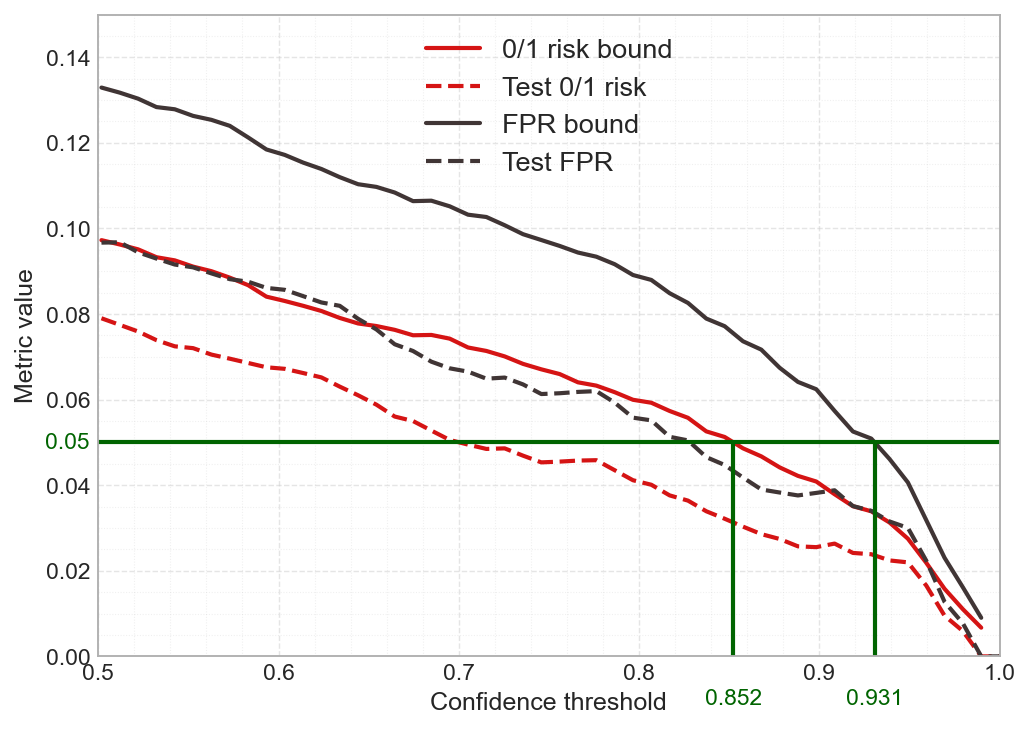

In [16]:
# -------------------- STYLE (visual only) --------------------
_rc = {
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.facecolor": "white",
    "legend.edgecolor": "#D0D0D0",
    "grid.alpha": 0.45,
    "lines.linewidth": 2.0,
}
# -------------------------------------------------------------

label_map = {
    'standard': '0/1 risk',
    'FPR': 'FPR'
}
level = 0.05

def _interpolated_crossing(t, b, level=level):
    """
    Return theta where b crosses down through `level`, via linear interpolation.
    Handles:
      - exact hits (b == level),
      - sign changes (> level to <= level),
      - no-crossing (returns closest point to level).
    """
    t = np.asarray(t, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - level

    # Exact hits first
    hit_idx = np.where(d == 0)[0]
    if hit_idx.size > 0:
        return float(t[hit_idx[0]])

    # Indices where signbit changes (crossing level)
    sign_changes = np.where(np.diff(np.signbit(d)))[0]
    for i in sign_changes:
        # ensure it's a downward crossing (b[i] > level, b[i+1] < level)
        if b[i] > level and b[i+1] < level:
            t0, t1 = t[i], t[i+1]
            b0, b1 = b[i], b[i+1]
            # linear interpolation fraction where b hits 'level'
            frac = (b0 - level) / (b0 - b1) if b0 != b1 else 0.0
            return float(t0 + frac * (t1 - t0))

    # If we got here, no downward crossing — snap to closest value
    return float(t[np.argmin(np.abs(d))])

def plot_metrics_on_ax(ax, metrics_subset, label_getter):
    last_thetas = None
    crossings = {}  # metric -> theta at level (interpolated)

    for metric in metrics_subset:
        color = color_map[metric]
        thetas, bounds = bound_evo_w_theta(metric, train_set_SR, delta, steps=50)
        last_thetas = thetas

        thetas_arr = np.asarray(thetas, dtype=float)
        bounds_arr = np.asarray(bounds, dtype=float)

        # Interpolated (robust) crossing
        crossings[metric] = _interpolated_crossing(thetas_arr, bounds_arr, level=level)

        # Train bound curve
        ax.plot(thetas_arr, bounds_arr, color=color,
                label=label_getter(metric) + ' bound', linewidth=2)

        # Test empirical metric
        emp_metrics, test_coverages, pos_props = [], [], []
        for theta in thetas_arr:
            selected_set = test_set_SR.loc[test_set_SR.kappa >= theta].copy()
            pos_props.append(selected_set.y_true.sum() / selected_set.shape[0])
            test_coverages.append(selected_set.shape[0] / test_set_SR.shape[0])
            try:
                emp_metrics.append(emp_metric(selected_set, metric=metric))
            except ValueError:
                emp_metrics.append(np.nan)

        ax.plot(thetas_arr, emp_metrics, linestyle='--', color=color,
                label='Test ' + label_getter(metric), linewidth=2)

    # Formatting
    ax.set_xlim(0.5, 1)
    ax.set_xlabel('Confidence threshold')
    ax.set_ylim(0, 0.15)
    ax.set_ylabel('Metric value')
    ax.legend(fontsize=13, loc="upper center")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Green guide style: match bound thickness
    green_style = dict(color='darkgreen', linestyle='-', linewidth=2)

    # Horizontal green line at y=level
    ax.axhline(y=level, **green_style)

    # Label "level" in green just left of the y-axis at the line
    ax.text(-0.01, level, str(level), color='darkgreen',
            transform=ax.get_yaxis_transform(), va='center', ha='right')

    # Vertical green lines at each metric's crossing, from x-axis up to level
    ymin, ymax = ax.get_ylim()
    for m in ('standard', 'FPR'):
        if m in crossings and crossings[m] is not None:
            xval = crossings[m]
            ax.vlines(xval, ymin=ymin, ymax=level, **green_style)

            # Add green text label of xval at bottom (just below x-axis ticks)
            ax.text(xval, ymin - 0.05 * (ymax - ymin),
                    f"{xval:.3f}", color='darkgreen',
                    ha='center', va='top')

# ====================== DRAW THE PLOT (styled) ======================
with plt.rc_context(_rc), plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(7, 5))

    metrics_to_plot = ['standard', 'FPR']
    plot_metrics_on_ax(ax, metrics_to_plot, lambda m: label_map[m])

    # Beautify axes (style only)
    for spine in ax.spines.values():
        spine.set_color("#B0B0B0")
        spine.set_linewidth(0.9)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()
# ==============================================================